# CNN (3-Conv) + mRMR + SVM Hybrid
**Pipeline:** Custom 3-layer CNN -> 128-d FC embeddings -> mRMR feature selection (K=32) -> SVM classifier  
All outputs saved to `3conResults/`


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library and scientific computing ─────────────────
# os/numpy/pandas/matplotlib/tqdm: I/O, arrays, results, charts
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch and sklearn pipeline ───────────────────────────────
# torch/nn/optim/F : model, layers, optimiser, activations
# sklearn          : SVM, StandardScaler, mRMR (mutual_info_classif)
# joblib.dump      : persist scaler and SVM to .joblib files
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets


# Evaluation: classification report, confusion matrix, P/R/F1
# StandardScaler   : zero-mean unit-variance for SVM input
# SVC              : Support Vector Classifier (RBF kernel)
# mutual_info_classif: MI scores for mRMR feature ranking
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from joblib import dump


# ── Paths ──────────────────────────────────────────────────────
# Same pre-split dataset as all other CNN experiments.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks/Custom"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "CNN3_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Hyperparameters ────────────────────────────────────────────
# LR=1e-4   : trained from scratch — higher than pretrained (1e-5)
# K_MRMR=32 : 32 features selected from the 128-d embedding
# No ImageNet normalisation — only Resize + ToTensor
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-4
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
K_MRMR          = 32
NUM_WORKERS     = 0


# CUDA required; cudnn.benchmark=True for fixed-size input tuning
# ── CUDA setup ──────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# Fix all random seeds for full reproducibility
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN3_May11_Results
GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [2]:
# ================================================
# Cell 2 — Dataset Loading
# ================================================
# Enforces numeric class order: 0, 100, 500, 1000, 1500, 2000
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# ── Image transform ────────────────────────────────────────────
# Custom CNNs: Resize + ToTensor only — no ImageNet normalisation,
# no augmentation. Same transform for train and evaluation.
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


# Load all three pre-split dataset folders
# Load directly from pre-split folders (no Subset needed)
train_ds = OrderedImageFolder(root=TRAIN_PATH, transform=transform)
val_ds   = OrderedImageFolder(root=VAL_PATH,   transform=transform)
test_ds  = OrderedImageFolder(root=TEST_PATH,  transform=transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# train_loader: shuffled | val/test loaders: unshuffled
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Data loaders ready.")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.


In [3]:
# ================================================
# Cell 3 — Model: Custom 3-Conv CNN
# ================================================
# Spatial flow (224x224 input):
#   conv1 + pool -> 112
#   conv2 + pool ->  56
#   conv3 + pool ->  28  -> AdaptiveAvgPool(1,1)
# Channel flow: 3 -> 32 -> 64 -> 128
# FC: 128 -> 128 (128-d embedding for SVM) -> num_classes
# ================================================
# ── Model architecture — Custom3CNN ────────────────────────────
# Adds one convolutional layer over CNN2, doubling the channel depth.
# Spatial flow: 224 -> 112 (conv1+pool) -> 56 (conv2+pool)
#               -> 28 (conv3+pool) -> 1x1 (AdaptiveAvgPool)
# Channel flow: 3 -> 32 -> 64 -> 128
# The AdaptiveAvgPool output is 128-d, feeding directly into fc1.
# Embedding head: Linear(128->128) -> 128-d embedding for SVM
# Dropout(0.4) regularises the final classification layer.
class Custom3CNN(nn.Module):
    def __init__(self, num_classes=6, p_drop=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,  64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool          = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout       = nn.Dropout(p_drop)
        self.fc1           = nn.Linear(128, 128)         # 128-d embedding
        self.fc2           = nn.Linear(128, num_classes)
        self.feature_maps  = None

    def forward(self, x, return_embedding=False):
        x = self.pool(F.relu(self.conv1(x)))             # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))             # 112 ->  56
        x = self.pool(F.relu(self.conv3(x)))             #  56 ->  28
        self.feature_maps = x
        x   = self.adaptive_pool(x).view(x.size(0), -1)  # (B, 128)
        emb = F.relu(self.fc1(x))                        # (B, 128) embedding
        logits = self.fc2(self.dropout(emb))
        if return_embedding:
            return logits, emb
        return logits

model     = Custom3CNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom3CNN — trainable parameters: {total_params:,}")


Custom3CNN — trainable parameters: 110,534


/tmp/ipykernel_21913/2169712516.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp        = torch.cuda.amp.GradScaler()


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_21913/2169712516.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_21913/2169712516.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 49/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 49]  Train Acc: 0.6150  Val Acc: 0.6073  Train Loss: 0.8564  Val Loss: 0.8890


Epoch 50/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 50]  Train Acc: 0.6189  Val Acc: 0.6220  Train Loss: 0.8552  Val Loss: 0.8455

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN3_May11_Results/best_custom_3cnn_model.pth


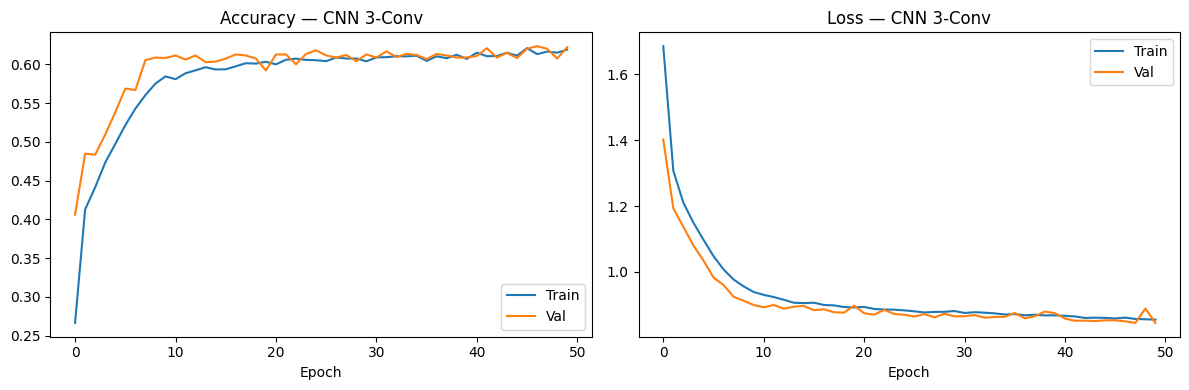

Training curves saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_custom_3cnn_model.pth")

# AMP GradScaler: enables float16 training without gradient underflow
scaler_amp        = torch.cuda.amp.GradScaler()

# Track best val_loss; save model whenever it improves
best_val_loss     = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop: train -> validate -> early stop -> save best ──
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# Plot and save training/validation accuracy and loss per epoch
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train'); axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — CNN 3-Conv"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(train_loss_hist, label='Train'); axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — CNN 3-Conv"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")


     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0           500       NO 
     5             0           500       NO 
     6             0             0       YES
     7             0           500       NO 
     8             0             0       YES
     9             0             0       YES
    10             0             0       YES
    11             0          1000       NO 
    12             0           500       NO 
    13             0           500       NO 
    14             0          1500       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0           500       NO 
    20             0           500       NO 
    21             0           500       NO 
    22    

/tmp/ipykernel_21913/2589065466.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    96             0             0       YES
    97             0           500       NO 
    98             0             0       YES
    99             0           500       NO 
   100             0           500       NO 
   101             0             0       YES
   102             0             0       YES
   103             0             0       YES
   104             0             0       YES
   105             0             0       YES
   106             0           500       NO 
   107             0             0       YES
   108             0             0       YES
   109             0             0       YES
   110             0             0       YES
   111             0             0       YES
   112             0             0       YES
   113             0             0       YES
   114             0             0       YES
   115             0           500       NO 
   116             0           500       NO 
   117             0             0       YES
   118    

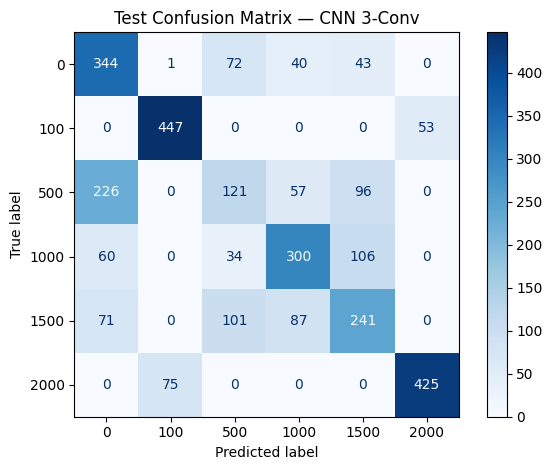


Classification Report — CNN 3-Conv:
              precision    recall  f1-score   support

           0     0.4907    0.6880    0.5729       500
         100     0.8547    0.8940    0.8739       500
         500     0.3689    0.2420    0.2923       500
        1000     0.6198    0.6000    0.6098       500
        1500     0.4959    0.4820    0.4888       500
        2000     0.8891    0.8500    0.8691       500

    accuracy                         0.6260      3000
   macro avg     0.6199    0.6260    0.6178      3000
weighted avg     0.6199    0.6260    0.6178      3000



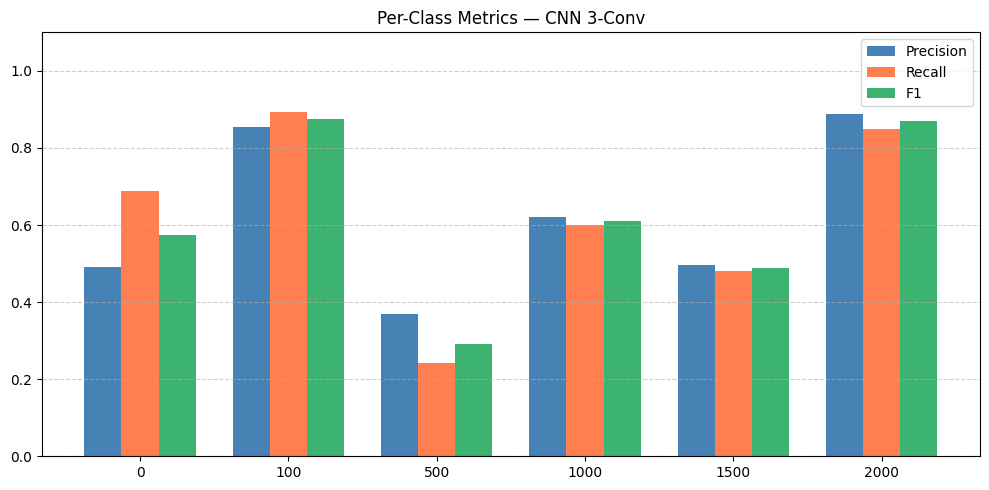

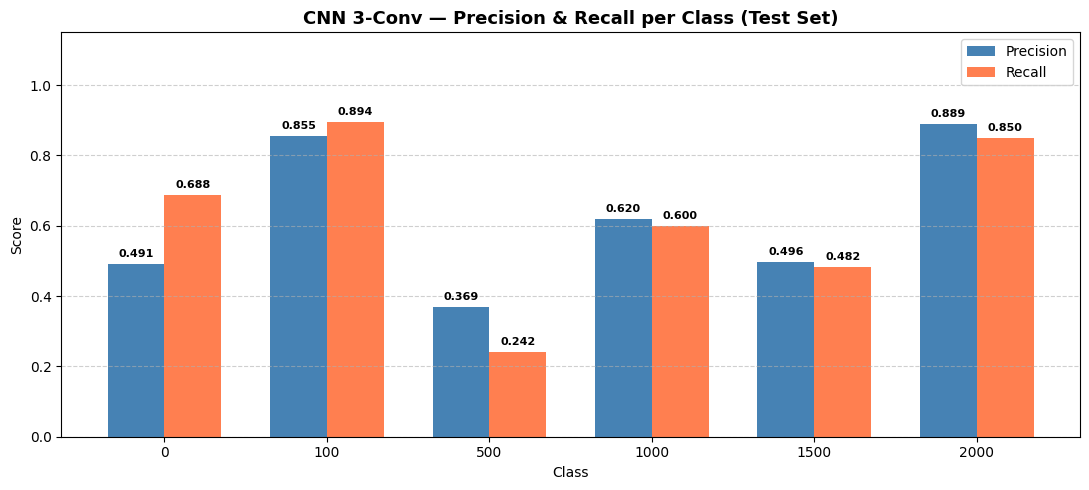

CNN Precision & Recall chart saved.


/tmp/ipykernel_21913/2589065466.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_21913/2589065466.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



CNN 3-Conv — Inference Time (100 random samples)
  Average : 0.671 ms / sample
  Std Dev : 0.104 ms
  Min     : 0.513 ms
  Max     : 0.911 ms
CNN inference times saved.


In [5]:
# ================================================
# Cell 5 — CNN Test Evaluation + Inference Print
# ================================================
import time

# Load best checkpoint (lowest val_loss) for final evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct   = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (CNN 3-Conv): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — CNN 3-Conv")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_cnn.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — CNN 3-Conv:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_cnn.txt"), "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report_cnn.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
cnn_precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
cnn_recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
cnn_f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, cnn_precision, w, label='Precision', color='steelblue')
plt.bar(x,     cnn_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, cnn_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — CNN 3-Conv")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_cnn.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, cnn_precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, cnn_recall,    w2, label='Recall',    color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, cnn_precision[i] + 0.02, f'{cnn_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, cnn_recall[i]    + 0.02, f'{cnn_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 3-Conv — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_cnn.png"), dpi=150)
plt.show()
print("CNN Precision & Recall chart saved.")


# Save per-sample true label, predicted label, correct flag
# ── Raw predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_cnn.csv"), index=False)

# ================================================
# CNN Inference Time — 100 random test samples
# ================================================
_rng100        = np.random.RandomState(SEED)
_sample_idx    = _rng100.choice(len(test_ds), 100, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0)

with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    with torch.cuda.amp.autocast():
        _ = model(_warm.to(DEVICE))
torch.cuda.synchronize()

cnn_times_ms = []
model.eval()
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast():
            _ = model(_inp)
        torch.cuda.synchronize()
        cnn_times_ms.append((time.perf_counter() - _t0) * 1000)

cnn_avg_time_ms = float(np.mean(cnn_times_ms))
cnn_std_time_ms = float(np.std(cnn_times_ms))

print("\n" + "="*52)
print("CNN 3-Conv — Inference Time (100 random samples)")
print("="*52)
print(f"  Average : {cnn_avg_time_ms:.3f} ms / sample")
print(f"  Std Dev : {cnn_std_time_ms:.3f} ms")
print(f"  Min     : {np.min(cnn_times_ms):.3f} ms")
print(f"  Max     : {np.max(cnn_times_ms):.3f} ms")
print("="*52)

pd.DataFrame({"sample": range(100), "cnn_time_ms": cnn_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "cnn_inference_times.csv"), index=False)
print("CNN inference times saved.")

In [6]:
# ================================================
# Cell 6 — Feature Extraction  (save embeddings)
# ================================================
# ── Feature extraction ─────────────────────────────────────────
# Extracts 128-d embeddings for train/val/test via return_embedding=True.
# Saved as .npy files for mRMR selection, SVM training, and PCA.
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE)
            with torch.cuda.amp.autocast():
                _, emb = model(inputs, return_embedding=True)  # (B, 128)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

train_embs, train_y = extract_embeddings(train_loader, model, "train")
val_embs,   val_y   = extract_embeddings(val_loader,   model, "val")
test_embs,  test_y  = extract_embeddings(test_loader,  model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [("train_embs", train_embs), ("val_embs",  val_embs),
                  ("test_embs",  test_embs),  ("train_y",   train_y),
                  ("val_y",      val_y),       ("test_y",    test_y)]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")

Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_21913/3616339946.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 128)  val: (1500, 128)  test: (3000, 128)
  Saved train_embs.npy  shape=(10500, 128)
  Saved val_embs.npy  shape=(1500, 128)
  Saved test_embs.npy  shape=(3000, 128)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


Running mRMR: 12000 samples, 128 features -> selecting K=32 ...


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 selected features (by MI):
 feature_index       mi
           102 0.815073
            30 0.808831
            80 0.805707
            69 0.805553
            70 0.804942
            64 0.803715
           118 0.798975
            27 0.768738
            39 0.768074
           116 0.765434


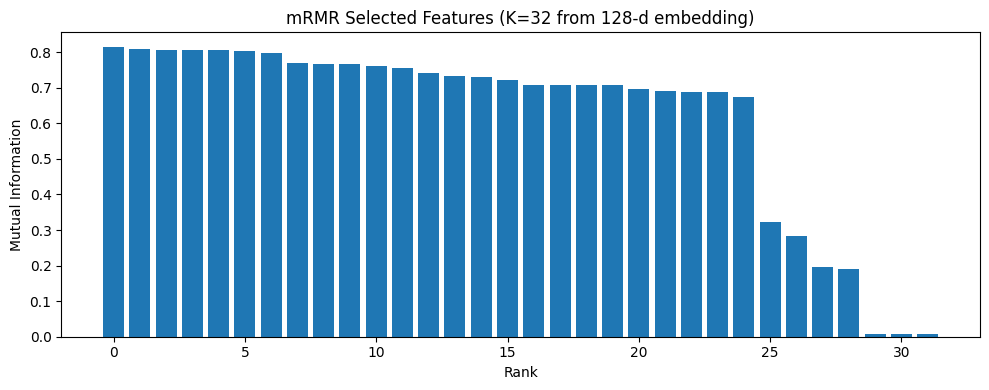

Reduced embedding: 32-d


In [7]:
# ================================================
# Cell 7 — mRMR Feature Selection
# ================================================
# ── mRMR greedy feature selection ──────────────────────────────
# Selects K=32 features from 128-d embeddings by maximising
# MI(feature, label) while minimising correlation with already-
# selected features. Fitted on combined train+val embeddings.
def mrmr_select(X, y, k, seed=SEED):
    """
    Greedy mRMR:
      relevance  = MI(feature, label)
      redundancy = mean |corr| to already-selected features
      score      = relevance - redundancy
    """
    X, y = np.asarray(X), np.asarray(y)
    k    = min(k, X.shape[1])
    mi   = mutual_info_classif(X, y, random_state=seed, discrete_features=False)
    corr = np.nan_to_num(np.abs(np.corrcoef(X, rowvar=False)), nan=0.0)

    selected  = [int(np.argmax(mi))]
    candidate = set(range(X.shape[1])) - set(selected)

    while len(selected) < k and candidate:
        scores    = {f: mi[f] - np.mean(corr[f, selected]) for f in candidate}
        best_feat = max(scores, key=scores.get)
        selected.append(best_feat)
        candidate.remove(best_feat)

    return selected, mi


# Combine train+val embeddings for more reliable MI estimation
X_tv = np.vstack([train_embs, val_embs])
y_tv = np.hstack([train_y,   val_y])

print(f"Running mRMR: {X_tv.shape[0]} samples, {X_tv.shape[1]} features -> selecting K={K_MRMR} ...")
selected_idx, mi = mrmr_select(X_tv, y_tv, k=K_MRMR)

sel_df = (pd.DataFrame({"feature_index": selected_idx, "mi": mi[selected_idx]})
            .sort_values("mi", ascending=False).reset_index(drop=True))
sel_df.to_csv(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}.csv"), index=False)

print(f"\nTop 10 selected features (by MI):")
print(sel_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(range(len(selected_idx)), sel_df["mi"].values)
plt.xlabel("Rank"); plt.ylabel("Mutual Information")
plt.title(f"mRMR Selected Features (K={K_MRMR} from 128-d embedding)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}_plot.png"), dpi=150)
plt.show()


# Reduce 128-d embeddings to 32-d using mRMR-selected indices
train_sel = train_embs[:, selected_idx]
val_sel   = val_embs[:,   selected_idx]
test_sel  = test_embs[:,  selected_idx]
print(f"Reduced embedding: {train_sel.shape[1]}-d")

Training SVM (RBF, C=10) ...
SVM training done.

SVM INFERENCE — per sample
     #    True Label    Pred Label   Correct
     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0           500       NO 
     6             0             0       YES
     7             0          1500       NO 
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0          1000       NO 
    12             0           500       NO 
    13             0           500       NO 
    14             0          1500       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0    

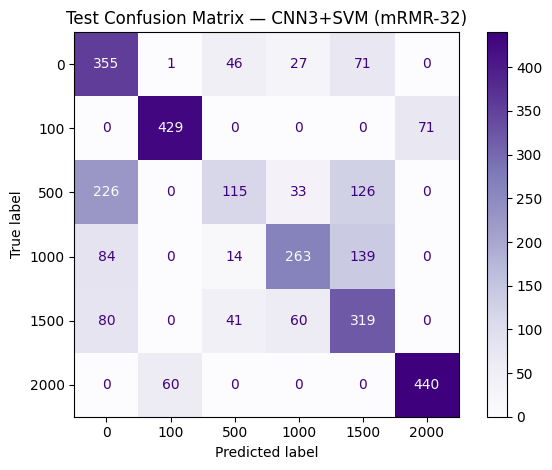


Classification Report — CNN3+SVM (mRMR-32):
              precision    recall  f1-score   support

           0     0.4765    0.7100    0.5703       500
         100     0.8755    0.8580    0.8667       500
         500     0.5324    0.2300    0.3212       500
        1000     0.6867    0.5260    0.5957       500
        1500     0.4870    0.6380    0.5524       500
        2000     0.8611    0.8800    0.8704       500

    accuracy                         0.6403      3000
   macro avg     0.6532    0.6403    0.6294      3000
weighted avg     0.6532    0.6403    0.6294      3000



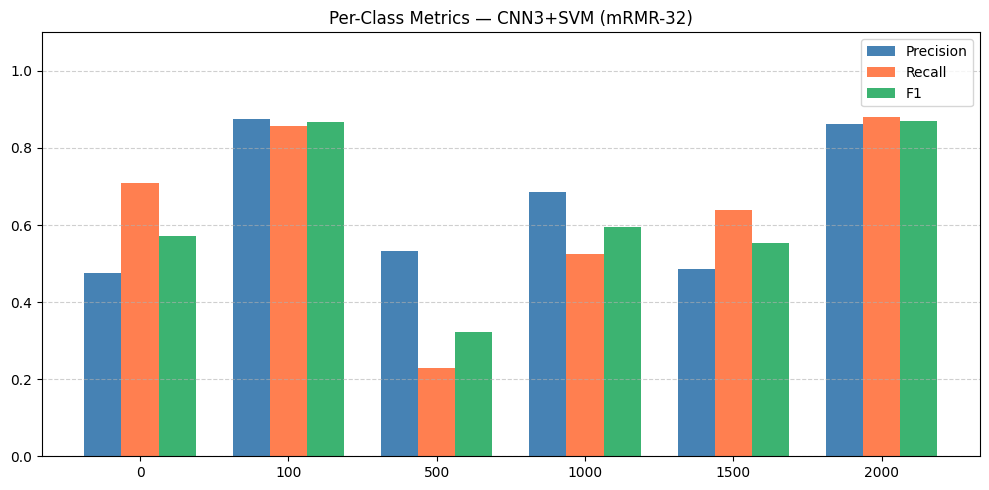

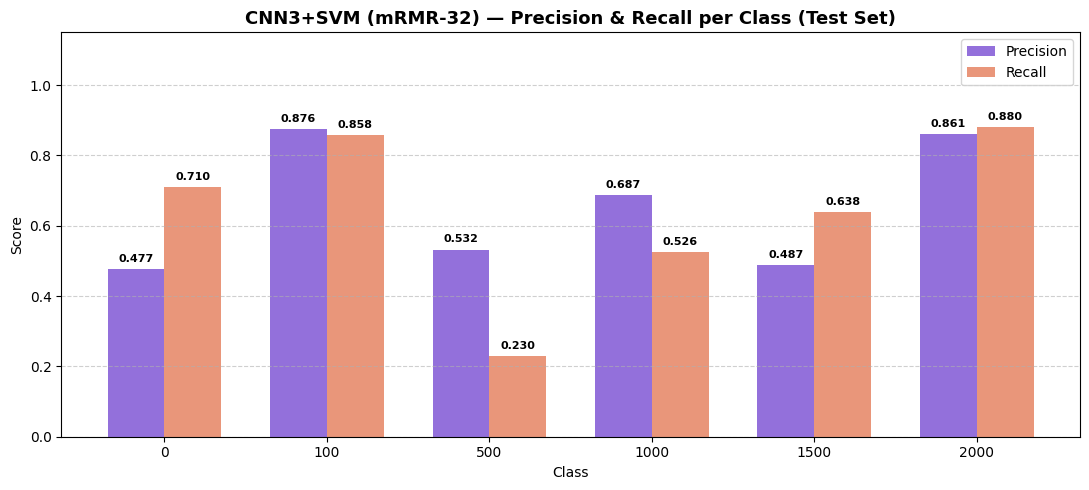

SVM Precision & Recall chart saved.


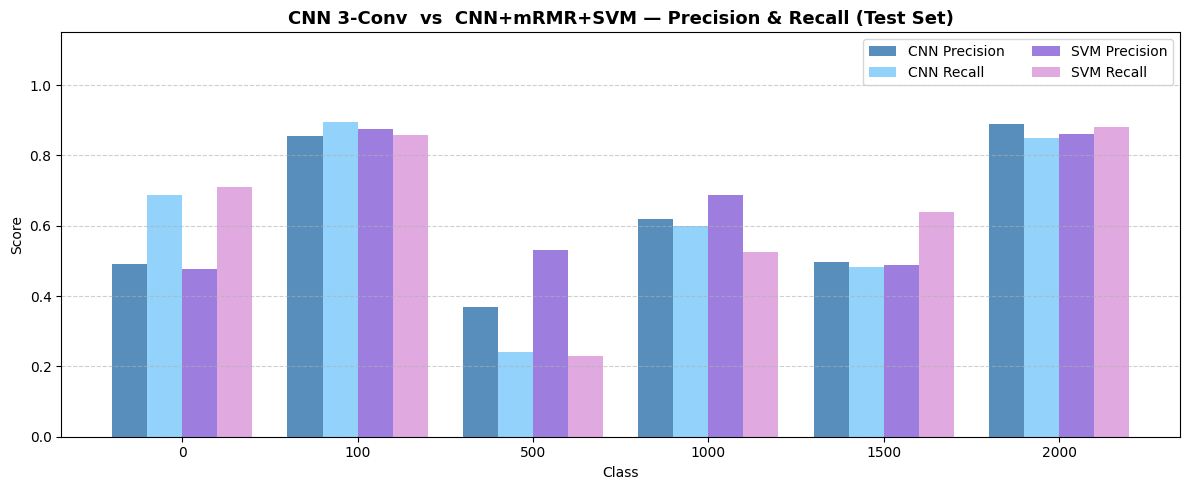

CNN vs SVM comparison chart saved.

SVM (mRMR-32) — Inference Time (100 random samples)
  Average : 0.5595 ms / sample
  Std Dev : 0.0721 ms
  Min     : 0.5014 ms
  Max     : 0.8695 ms

INFERENCE TIME SUMMARY (avg over 100 samples)
  CNN alone        : 0.671 ± 0.104 ms
  SVM alone (mRMR) : 0.5595 ± 0.0721 ms
  Full pipeline    : 1.231 ms  (CNN + SVM)

All artifacts saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN3_May11_Results
PCA_Analysis
best_custom_3cnn_model.pth
classification_report_cnn.csv
classification_report_cnn.txt
classification_report_svm_mrmr_32.csv
classification_report_svm_mrmr_32.txt
cnn_inference_times.csv
comparison_cnn_vs_svm_precision_recall.png
confusion_matrix_cnn.png
confusion_matrix_svm_mrmr_32.png
inference_time_summary.csv
mrmr_selected_32.csv
mrmr_selected_32_plot.png
per_class_metrics_cnn.png
per_class_metrics_svm_mrmr_32.png
precision_recall_cnn.png
precision_recall_svm_mrmr_32.png
predictions_cnn.csv
predictions_svm_mrmr_32.csv
scaler_mr

In [8]:
# ================================================
# Cell 8 — SVM Training + Evaluation + Inference
# ================================================
# ── SVM pipeline ───────────────────────────────────────────────
# StandardScaler: normalise 32-d features before SVM to prevent
# any single dimension dominating the RBF kernel distance.
# Fitted on train+val; transform applied to test only (no leakage).
scaler       = StandardScaler()
train_std    = scaler.fit_transform(np.vstack([train_sel, val_sel]))
test_std     = scaler.transform(test_sel)
y_train_full = np.hstack([train_y, val_y])

print("Training SVM (RBF, C=10) ...")
svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=False, random_state=SEED)
svm.fit(train_std, y_train_full)
print("SVM training done.")


# Save scaler and SVM for future inference without retraining
dump(scaler, os.path.join(OUTPUT_DIR, "scaler_mrmr_svm.joblib"))
dump(svm,    os.path.join(OUTPUT_DIR, "svm_mrmr_rbf.joblib"))


# Run SVM predictions on the full 3000-sample test set
# ── SVM Inference per sample ──
svm_preds = svm.predict(test_std)

print("\n" + "="*65)
print("SVM INFERENCE — per sample")
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)
for i, (true, pred) in enumerate(zip(test_y, svm_preds)):
    correct = "YES" if true == pred else "NO "
    print(f"{i:>6}  {CLASS_NAMES[true]:>12}  {CLASS_NAMES[pred]:>12}  {correct:>8}")
print("="*65)

svm_acc = (svm_preds == test_y).mean()
print(f"\nTest Accuracy (CNN3 + mRMR-{K_MRMR} + SVM): {svm_acc * 100:.2f}%")
print(f"Correct: {(svm_preds == test_y).sum()} / {len(test_y)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm_svm = confusion_matrix(test_y, svm_preds, labels=list(range(NUM_CLASSES)))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CLASS_NAMES)
disp.plot(cmap='Purples', values_format='d')
plt.title(f"Test Confusion Matrix — CNN3+SVM (mRMR-{K_MRMR})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
rep_txt = classification_report(test_y, svm_preds, target_names=CLASS_NAMES, digits=4)
print(f"\nClassification Report — CNN3+SVM (mRMR-{K_MRMR}):")
print(rep_txt)
with open(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.txt"), "w") as f:
    f.write(rep_txt)
pd.DataFrame(
    classification_report(test_y, svm_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
svm_precision = precision_score(test_y, svm_preds, average=None, labels=range(NUM_CLASSES))
svm_recall    = recall_score(test_y,    svm_preds, average=None, labels=range(NUM_CLASSES))
svm_f1        = f1_score(test_y,       svm_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 (SVM) ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, svm_precision, w, label='Precision', color='steelblue')
plt.bar(x,     svm_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, svm_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title(f"Per-Class Metrics — CNN3+SVM (mRMR-{K_MRMR})")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"per_class_metrics_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart (SVM) ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, svm_precision, w2, label='Precision', color='mediumpurple')
plt.bar(x + w2/2, svm_recall,    w2, label='Recall',    color='darksalmon')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, svm_precision[i] + 0.02, f'{svm_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, svm_recall[i]    + 0.02, f'{svm_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title(f"CNN3+SVM (mRMR-{K_MRMR}) — Precision & Recall per Class (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"precision_recall_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()
print("SVM Precision & Recall chart saved.")


# CNN vs SVM comparison: grouped precision/recall bars per class
# ── Chart 3: CNN vs SVM comparison (Precision & Recall same chart) ──
w3 = 0.2
plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w3, cnn_precision, w3, label='CNN Precision',     color='steelblue',    alpha=0.9)
plt.bar(x - 0.5*w3, cnn_recall,    w3, label='CNN Recall',        color='lightskyblue', alpha=0.9)
plt.bar(x + 0.5*w3, svm_precision, w3, label='SVM Precision',     color='mediumpurple', alpha=0.9)
plt.bar(x + 1.5*w3, svm_recall,    w3, label='SVM Recall',        color='plum',         alpha=0.9)
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 3-Conv  vs  CNN+mRMR+SVM — Precision & Recall (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(ncol=2); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_cnn_vs_svm_precision_recall.png"), dpi=150)
plt.show()
print("CNN vs SVM comparison chart saved.")

# ── Predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(test_y)),
    "True Label": [CLASS_NAMES[i] for i in test_y],
    "Pred Label": [CLASS_NAMES[i] for i in svm_preds],
    "Correct":    (svm_preds == test_y).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, f"predictions_svm_mrmr_{K_MRMR}.csv"), index=False)

# ================================================
# SVM Inference Time — same 100 random test samples
# ================================================
_rng100     = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_y), 100, replace=False)
_test_100   = test_std[_sample_idx]

_ = svm.predict(_test_100[:1])   # warm-up

svm_times_ms = []
for i in range(100):
    _t0 = time.perf_counter()
    _   = svm.predict(_test_100[i : i + 1])
    svm_times_ms.append((time.perf_counter() - _t0) * 1000)

svm_avg_time_ms = float(np.mean(svm_times_ms))
svm_std_time_ms = float(np.std(svm_times_ms))

print("\n" + "="*55)
print(f"SVM (mRMR-{K_MRMR}) — Inference Time (100 random samples)")
print("="*55)
print(f"  Average : {svm_avg_time_ms:.4f} ms / sample")
print(f"  Std Dev : {svm_std_time_ms:.4f} ms")
print(f"  Min     : {np.min(svm_times_ms):.4f} ms")
print(f"  Max     : {np.max(svm_times_ms):.4f} ms")
print("="*55)

pd.DataFrame({"sample": range(100), "svm_time_ms": svm_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, f"svm_inference_times_{K_MRMR}.csv"), index=False)


# Inference time breakdown: CNN alone / SVM alone / full pipeline
# ── Final Summary ──
pipeline_avg = cnn_avg_time_ms + svm_avg_time_ms
print("\n" + "="*55)
print("INFERENCE TIME SUMMARY (avg over 100 samples)")
print("="*55)
print(f"  CNN alone        : {cnn_avg_time_ms:.3f} ± {cnn_std_time_ms:.3f} ms")
print(f"  SVM alone (mRMR) : {svm_avg_time_ms:.4f} ± {svm_std_time_ms:.4f} ms")
print(f"  Full pipeline    : {pipeline_avg:.3f} ms  (CNN + SVM)")
print("="*55)

pd.DataFrame({
    "Stage":   ["CNN only", f"SVM mRMR-{K_MRMR}", "Full Pipeline"],
    "Avg_ms":  [round(cnn_avg_time_ms, 4), round(svm_avg_time_ms, 4), round(pipeline_avg, 4)],
    "Std_ms":  [round(cnn_std_time_ms, 4), round(svm_std_time_ms, 4), "-"],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)

print("\n" + "="*50)
print("All artifacts saved in:", OUTPUT_DIR)
print("="*50)
print(os.linesep.join(sorted(os.listdir(OUTPUT_DIR))))

Embeddings : (3000, 128)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN3_May11_Results/PCA_Analysis

Explained variance: PC1=0.914  PC2=0.050  Total=0.963


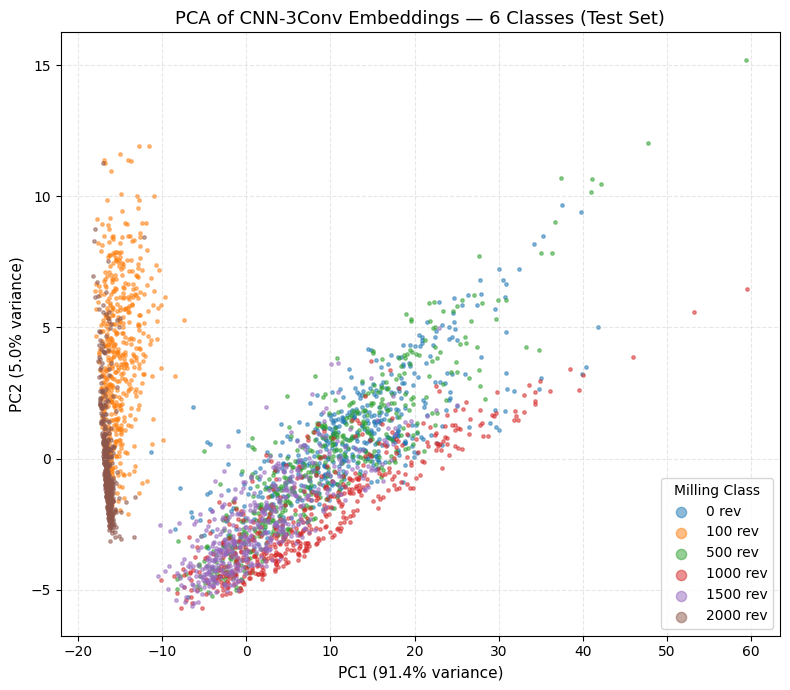

Saved: pca_embeddings.png


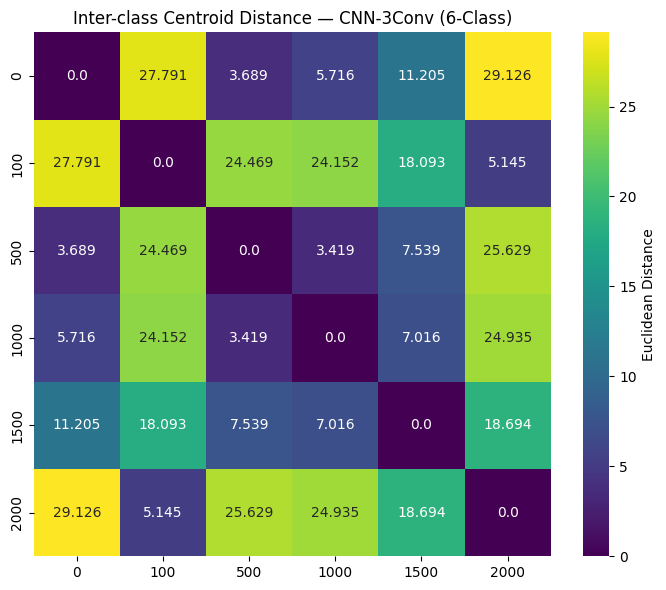

Saved: distance_heatmap.png


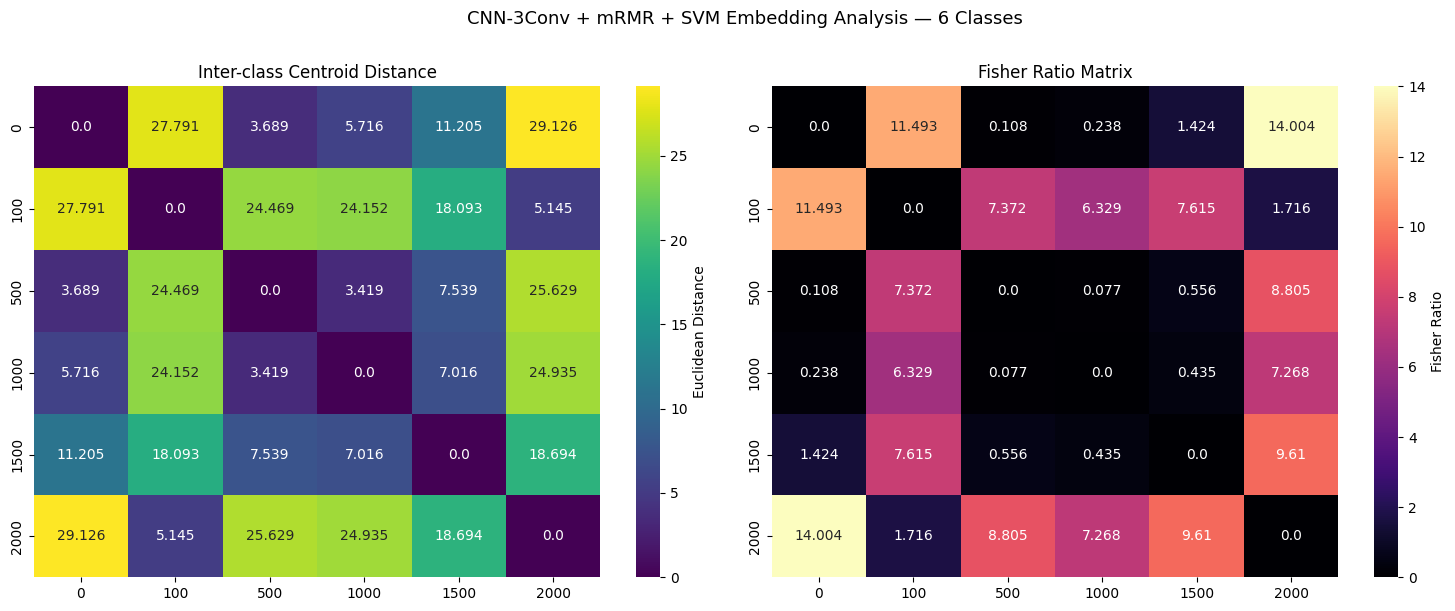

Saved: distance_fisher_side_by_side.png


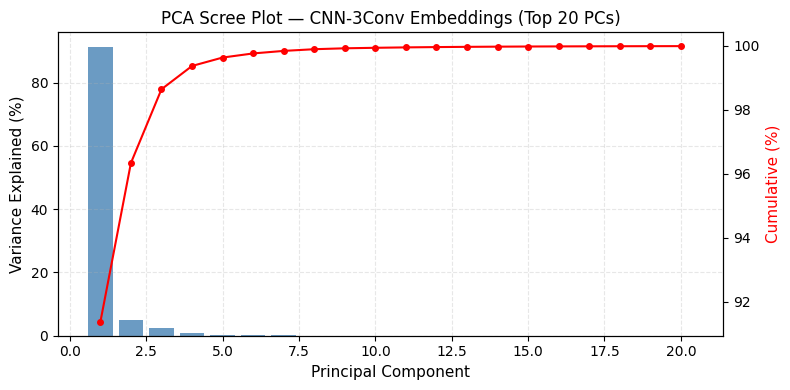

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN3_May11_Results/PCA_Analysis
PC1+PC2 explains : 96.3%
PCs for 95% var  : 2


In [9]:
# ================================================
# Cell 9 — PCA Analysis of CNN Embeddings
# ================================================
# seaborn/scipy/sklearn PCA: heatmaps, centroid distances, 2D projection
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# Load 128-d CNN embeddings for PCA (raw features, not mRMR-reduced)
# Load CNN embeddings saved by Cell 6
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV (SVM predictions saved by Cell 8)
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 8 first."
pred_df      = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 128-d embeddings to 2 PCs. Cluster separation reflects
# CNN feature discriminability — more separated than CNN2 expected.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of CNN-3Conv Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# Inter-class centroid Euclidean distances in 128-d space
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — CNN-3Conv ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# Fisher ratio + distance heatmaps side by side for paper figure
# ── Fisher ratio + side-by-side ─────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'CNN-3Conv + mRMR + SVM Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# PCA scree: variance per component (bar) and cumulative (red line)
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — CNN-3Conv Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA metrics to CSV for reproducibility
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"\nAll PCA results saved to: {PCA_DIR}")
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")